## Introdução

- TRATAMENTO DE DADOS - G96 (sx-askubuntu)
- Matrícula: 222115971
- Autor: Matheus Oliveira Molinari Ramos

### Bibliotecas

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import os
import random
import time
from collections import Counter
from scipy import stats
import warnings

## Regra de Mapeamento da Matrícula

In [2]:
# Soma dos dígitos
soma_dos_digitos = 2 + 2 + 2 + 1 + 1 + 5 + 9 + 7 + 1
soma_dos_digitos

# Últimos dois dígitos
ultimos_dois_digitos = 71

# Grafo a ser utilizado
grafo = ((soma_dos_digitos) * (ultimos_dois_digitos + 1)) % 129
print(grafo)

96


### Grafo G96

- ID: 96
- Category: Temporal networks
- Name: sx-askubuntu
- Name_URL: https://snap.stanford.edu/data/sx-askubuntu.html
- Type: Directed, Temporal
- Nodes: 159,316
- Edges: 
- Communities: 
- Temporal_Edges:  964,437
- Static_Edges:  596,933
- Edges_Actions: 
- Number_of_items: 
- Number_of_graphs: 
- Description: Comments, questions, and answers on Ask Ubuntu

## Tratamento dos Dados 

In [3]:
df_temporal = pd.read_csv('sx-askubuntu.txt.gz', sep=' ', header=None, names=['source', 'target', 'timestamp'],)
print(f"Total de arestas temporais: {len(df_temporal)}")

Total de arestas temporais: 964437


In [ ]:
"""
Aplicando filtragem temporal

- Opção escolhida: Manter todos os timestamps (grafo temporal completo)
- Exemplo de opção:
    ano_inicio = 2015
    ano_fim = 2016
    df_temporal = df_raw[(df_raw['timestamp'] >= ano_inicio) & df_raw['timestamp'] <= ano_fim)]
    print(f" Filtro aplicado: {ano_inicio} a {ano_fim}")
"""

In [4]:
G_dir_temp = nx.DiGraph()
edges_list = list(zip(df_temporal['source'], df_temporal['target']))
G_dir_temp.add_edges_from(edges_list)

print(f"Grafo estático direcionado:")
print(f"Vértices: {G_dir_temp.number_of_nodes()}")
print(f"Arestas únicas: {G_dir_temp.number_of_edges()}")

Grafo estático direcionado:
Vértices: 159316
Arestas únicas: 596933


In [5]:
# Removendo auto-loops

num_selfloops = sum(1 for u, v in G_dir_temp.edges() if u == v)
G_dir_temp.remove_edges_from(nx.selfloop_edges(G_dir_temp))

print(f"Removidos {num_selfloops} auto-loops")
print(f"Arestas após remoção: {G_dir_temp.number_of_edges()}")

Removidos 52312 auto-loops
Arestas após remoção: 544621


In [6]:
# Convertendo grafo dirigido para não direcionado

G_und = nx.Graph(G_dir_temp)  # A conversão para Graph já remove multigrafos

print(f"Grafo não direcionado:")
print(f"Vértices: {G_und.number_of_nodes()}")
print(f"Arestas: {G_und.number_of_edges()}")

Grafo não direcionado:
Vértices: 159316
Arestas: 455691


In [7]:
# Extraindo a Maior Componente Conexa

# Lista todas as componentes
components = list(nx.connected_components(G_und))
num_components = len(components)
sizes = [len(c) for c in components]
largest_size = max(sizes)
largest_comp = max(components, key=len)
print(f"Número total de componentes: {num_components}")

# Cria o grafo da maior componente
G_gcc = G_und.subgraph(largest_comp).copy()
print(f"\nGrafo da Maior Componente Conexa:")
print(f"Vértices: {G_gcc.number_of_nodes()}")
print(f"Arestas: {G_gcc.number_of_edges()}")
print(f"Densidade: {nx.density(G_gcc):.9f}")

Número total de componentes: 4250

Grafo da Maior Componente Conexa:
Vértices: 152599
Arestas: 453221
Densidade: 0.000038926


In [8]:
# Lista de adjacência (NetworkX já fornece)
adj_list = nx.to_dict_of_lists(G_gcc)
with open('g96_adjacency_list.txt', 'w') as f:
    for node, neighbors in adj_list.items():
        f.write(f"{node}: {','.join(map(str, neighbors))}\n")
print("Lista de adjacência salva em 'g96_adjacency_list.txt'")

# Matriz de adjacência (esparsa)
edge_list = list(G_gcc.edges())
edge_df = pd.DataFrame(edge_list, columns=['source', 'target'])
edge_df.to_csv('g96_edge_list.csv', index=False)
print(f"Lista de arestas salva em 'g96_edge_list.csv'")

# Matriz de adjacência para subgrafo pequeno (Para demonstrar a matriz com os 20 primeiros nós)
nodes_subset = list(G_gcc.nodes())[:20]
G_sub = G_gcc.subgraph(nodes_subset)
adj_matrix = nx.to_numpy_array(G_sub)
print(f"\nMatriz de adjacência (20x20) criada para demonstração:")
print(adj_matrix[:20, :20])

Lista de adjacência salva em 'g96_adjacency_list.txt'
Lista de arestas salva em 'g96_edge_list.csv'

Matriz de adjacência (20x20) criada para demonstração:
[[0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 1. 0. 0. 1. 0.

## Parte I - Análise Estrutural Obrigatória

In [9]:
degrees = [d for n, d in G_gcc.degree()]
degree_counts = Counter(degrees)

print(f"Número de vértices: {G_gcc.number_of_nodes()}")
print(f"Número de arestas: {G_gcc.number_of_edges()}")
print(f"Grau mínimo: {min(degrees)}")
print(f"Grau máximo: {max(degrees)}")
print(f"Grau médio: {np.mean(degrees):.6f}")
print(f"Densidade: {nx.density(G_gcc):.9f}")
print(f"Coeficiente de clusterização médio: {nx.average_clustering(G_gcc):.9f}")

Número de vértices: 152599
Número de arestas: 453221
Grau mínimo: 1
Grau máximo: 5401
Grau médio: 5.940026
Densidade: 0.000038926
Coeficiente de clusterização médio: 0.114107991


In [10]:
component_sizes = sorted(
    [len(c) for c in components],
    reverse=True
)

print(f"Número total de componentes: {num_components}")
print("Tamanho das componentes:")
print(component_sizes[:20])  # mostra as 20 maiores

Número total de componentes: 4250
Tamanho das componentes:
[152599, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4]


Calculando distribuição de graus
  - Grau mínimo: 1
  - Grau máximo: 5401
  - Grau médio: 5.94
  - Mediana: 2
  - Desvio padrão: 49.36


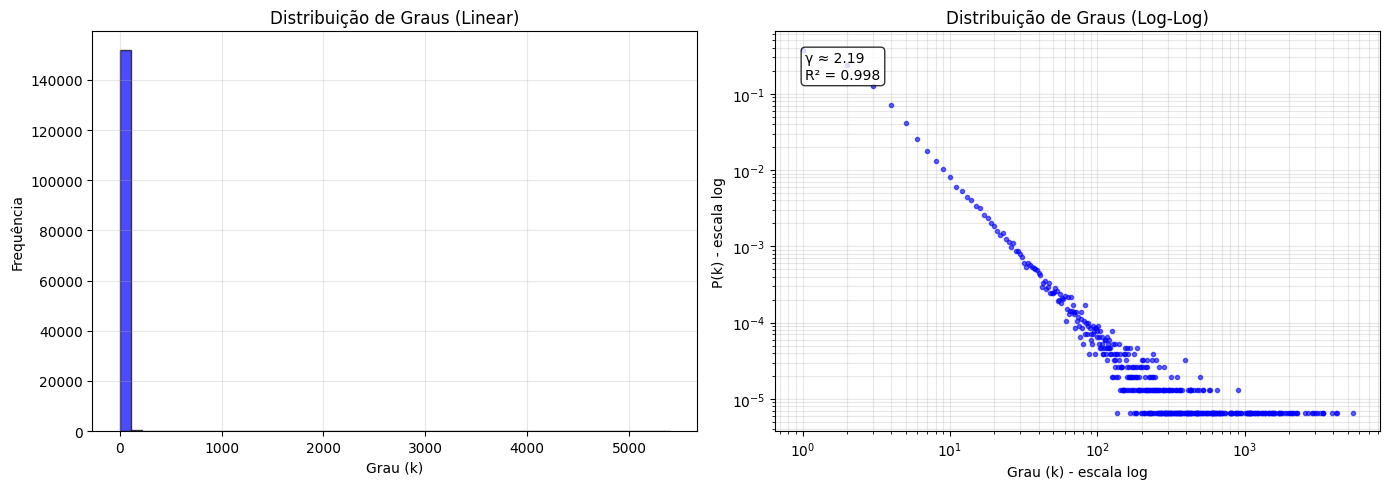

In [11]:
G = nx.read_graphml('g96_gcc.graphml')

print("Calculando distribuição de graus")

start_time = time.time()
degrees = [d for n, d in G.degree()]
degree_counts = Counter(degrees)
k_values = sorted(degree_counts.keys())
p_values = [degree_counts[k] / G.number_of_nodes() for k in k_values]

print(f"  - Grau mínimo: {min(degrees)}")
print(f"  - Grau máximo: {max(degrees)}")
print(f"  - Grau médio: {np.mean(degrees):.2f}")
print(f"  - Mediana: {np.median(degrees):.0f}")
print(f"  - Desvio padrão: {np.std(degrees):.2f}")

# Gráfico 1: Distribuição de graus (linear)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico linear
ax1.hist(degrees, bins=50, alpha=0.7, color='blue', edgecolor='black')
ax1.set_xlabel('Grau (k)')
ax1.set_ylabel('Frequência')
ax1.set_title('Distribuição de Graus (Linear)')
ax1.grid(True, alpha=0.3)

# Gráfico log-log (lei de potência)
ax2.loglog(k_values, p_values, 'bo', markersize=3, alpha=0.6)
ax2.set_xlabel('Grau (k) - escala log')
ax2.set_ylabel('P(k) - escala log')
ax2.set_title('Distribuição de Graus (Log-Log)')
ax2.grid(True, alpha=0.3, which='both')


from scipy import stats
log_k = np.log(k_values)
log_p = np.log(p_values)

valid_idx = (log_k > 0) & (np.isfinite(log_p))
if sum(valid_idx) > 10:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        log_k[valid_idx][:min(20, sum(valid_idx))], 
        log_p[valid_idx][:min(20, sum(valid_idx))]
    )
    ax2.text(0.05, 0.95, f'γ ≈ {-slope:.2f}\nR² = {r_value**2:.3f}', 
             transform=ax2.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('g96_distribuicao_graus.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
print("Calculando métricas de caminhos")

num_samples = min(100, G.number_of_nodes())
sources = np.random.choice(list(G.nodes()), size=num_samples, replace=False)

all_path_lengths = []
max_distances = []

print(f"Amostrando {num_samples} vértices fonte")

start_time = time.time()
for i, source in enumerate(sources):
    try:
        lengths = nx.single_source_shortest_path_length(G, source)
        distances = list(lengths.values())
        all_path_lengths.extend(distances)
        max_distances.append(max(distances))
    except:
        continue

avg_path_length = np.mean(all_path_lengths)
diameter_est = max(max_distances) if max_distances else 0
radius_est = min(max_distances) if max_distances else 0

print(f"Comprimento médio dos caminhos: {avg_path_length:.4f}")
print(f"Diâmetro estimado: {diameter_est}")
print(f"Raio estimado: {radius_est}")
print(f"Caminhos analisados: {len(all_path_lengths)}")

Calculando métricas de caminhos
Amostrando 100 vértices fonte
Comprimento médio dos caminhos: 3.9471
Diâmetro estimado: 10
Raio estimado: 8
Caminhos analisados: 15259900


In [13]:
print("Calculando número de triângulos")

triangles_dict = nx.triangles(G)
total_triangles = sum(triangles_dict.values()) // 3
print(f"Número total de triângulos: {total_triangles}")
print(f"Média de triângulos por vértice: {total_triangles / G.number_of_nodes():.2f}")

Calculando número de triângulos
Número total de triângulos: 680405
Média de triângulos por vértice: 4.46


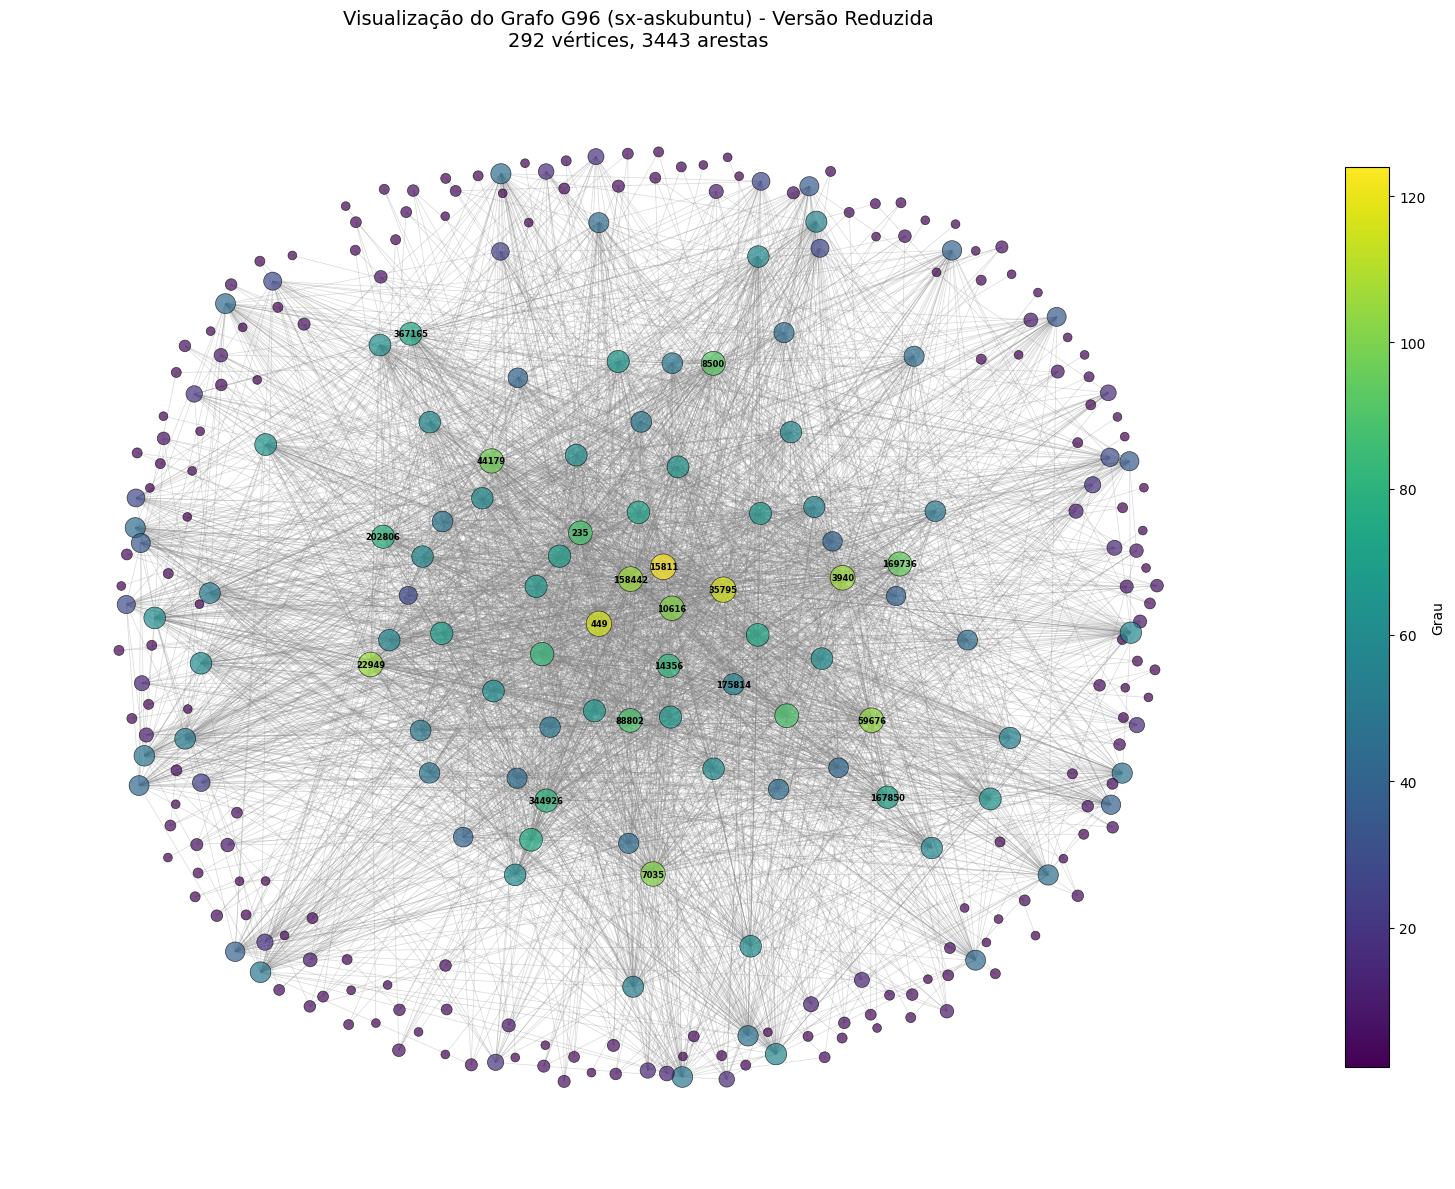

In [14]:
hubs = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:100]
hubs_nodes = [n for n, d in hubs]

additional_nodes = []
for node in hubs_nodes[:20]:
    neighbors = list(G.neighbors(node))
    if neighbors:
        sample_size = min(10, len(neighbors))
        additional_nodes.extend(np.random.choice(neighbors, size=sample_size, replace=False))

subgraph_nodes = list(set(hubs_nodes + additional_nodes))
G_sub = G.subgraph(subgraph_nodes)
pos = nx.spring_layout(G_sub, k=2, iterations=50, seed=42)

fig, ax = plt.subplots(figsize=(16, 12))

node_colors = [G_sub.degree(n) for n in G_sub.nodes()]
node_sizes = [np.sqrt(G_sub.degree(n)) * 30 + 10 for n in G_sub.nodes()]

nodes = nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors, 
                               node_size=node_sizes, cmap='viridis', 
                               alpha=0.7, edgecolors='black', linewidths=0.5, ax=ax)
edges = nx.draw_networkx_edges(G_sub, pos, alpha=0.3, edge_color='gray', 
                               width=0.5, ax=ax)

hub_labels = {n: str(n) for n in hubs_nodes[:20]}
nx.draw_networkx_labels(G_sub, pos, labels=hub_labels, font_size=6, 
                        font_weight='bold', ax=ax)

ax.set_title(f'Visualização do Grafo G96 (sx-askubuntu) - Versão Reduzida\n'
             f'{G_sub.number_of_nodes()} vértices, {G_sub.number_of_edges()} arestas',
             fontsize=14)

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Grau', shrink=0.8)

ax.axis('off')
plt.tight_layout()
plt.savefig('g96_visualizacao_reduzida.png', dpi=300, bbox_inches='tight')
plt.show()

## Parte II - Algoritmos da Disciplina 

In [15]:
def measure_time(func, *args, repeats=30, **kwargs):
    times = []
    result = None
    
    for i in range(repeats):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        times.append(end - start)
    
    mean = np.mean(times)
    std = np.std(times, ddof=1) 
    
    # Cálculo do intervalo de confiança
    n = len(times)
    if n >= 30:
        z_score = 1.96  
        ci = z_score * (std / np.sqrt(n))
        dist_type = "Normal (Z)"
    else:
        # Distribuição t-Student
        t_score = stats.t.ppf(0.975, df=n-1)
        ci = t_score * (std / np.sqrt(n))
        dist_type = "t-Student"
    
    return {
        'mean': mean,
        'std': std,
        'ci': ci,
        'times': times,
        'dist_type': dist_type,
        'n': n,
        'result': result 
    }

In [16]:
print("BUSCA EM LARGURA (BFS) - Complexidade Teórica:")
print("  - BFS: O(V + E)")
print(f"  - V = {G.number_of_nodes()}, E = {G.number_of_edges()}")
print(f"  - O(V + E) ≈ {G.number_of_nodes() + G.number_of_edges()} operações")

source_node = list(G.nodes())[0]
print(f"\nNó fonte: {source_node}")
bfs_result = measure_time(nx.bfs_tree, G, source=source_node, repeats=30)

print(f"\nResultados BFS:")
print(f"Tempo médio: {bfs_result['mean']:.6f} segundos")
print(f"Desvio padrão: {bfs_result['std']:.6f} segundos")
print(f"Intervalo de confiança (95%): ± {bfs_result['ci']:.6f} segundos")
print(f"Distribuição usada: {bfs_result['dist_type']}")
print(f"Número de repetições: {bfs_result['n']}")

BUSCA EM LARGURA (BFS) - Complexidade Teórica:
  - BFS: O(V + E)
  - V = 152599, E = 453221
  - O(V + E) ≈ 605820 operações

Nó fonte: 4

Resultados BFS:
Tempo médio: 2.297565 segundos
Desvio padrão: 0.436902 segundos
Intervalo de confiança (95%): ± 0.156343 segundos
Distribuição usada: Normal (Z)
Número de repetições: 30


In [17]:
print("BUSCA EM PROFUNDIDADE (DFS) - Complexidade Teórica:")
print("  - DFS: O(V + E)")
print(f"  - V = {G.number_of_nodes()}, E = {G.number_of_edges()}")
print(f"  - O(V + E) ≈ {G.number_of_nodes() + G.number_of_edges()} operações")

dfs_result = measure_time(nx.dfs_tree, G, source=source_node, repeats=30)

print(f"\nResultados DFS:")
print(f"Tempo médio: {dfs_result['mean']:.6f} segundos")
print(f"Desvio padrão: {dfs_result['std']:.6f} segundos")
print(f"Intervalo de confiança (95%): ± {dfs_result['ci']:.6f} segundos")
print(f"Distribuição usada: {dfs_result['dist_type']}")

BUSCA EM PROFUNDIDADE (DFS) - Complexidade Teórica:
  - DFS: O(V + E)
  - V = 152599, E = 453221
  - O(V + E) ≈ 605820 operações

Resultados DFS:
Tempo médio: 1.589150 segundos
Desvio padrão: 0.587996 segundos
Intervalo de confiança (95%): ± 0.210412 segundos
Distribuição usada: Normal (Z)


In [18]:
print("VERIFICAÇÃO DE EULERIANIDADE - Complexidade Teórica:")
print("  - Verificação de Eulerianidade: O(V + E)")
print(f"  - V = {G.number_of_nodes()}, E = {G.number_of_edges()}")
print(f"  - O(V + E) ≈ {G.number_of_nodes() + G.number_of_edges()} operações")

# Verifica se o grafo é Euleriano
is_eulerian = nx.is_eulerian(G)
if is_eulerian:
    print("O grafo é Euleriano (todos os vértices têm grau par)")
else:
    print("O grafo NÃO é Euleriano")
    # Conta quantos vértices têm grau ímpar
    odd_degree_nodes = [n for n, d in G.degree() if d % 2 == 1]
    print(f"Número de vértices com grau ímpar: {len(odd_degree_nodes)}")

eulerian_result = measure_time(nx.is_eulerian, G, repeats=30)
print(f"\nResultados Verificação de Eulerianidade:")
print(f"Tempo médio: {eulerian_result['mean']:.6f} segundos")
print(f"Desvio padrão: {eulerian_result['std']:.6f} segundos")
print(f"Intervalo de confiança (95%): ± {eulerian_result['ci']:.6f} segundos")


VERIFICAÇÃO DE EULERIANIDADE - Complexidade Teórica:
  - Verificação de Eulerianidade: O(V + E)
  - V = 152599, E = 453221
  - O(V + E) ≈ 605820 operações
O grafo NÃO é Euleriano
Número de vértices com grau ímpar: 93298

Resultados Verificação de Eulerianidade:
Tempo médio: 0.000003 segundos
Desvio padrão: 0.000003 segundos
Intervalo de confiança (95%): ± 0.000001 segundos


In [19]:
print("DIJKSTRA - Complexidade Teórica:")
print("  - Dijkstra (com heap): O((V + E) log V)")
print(f"  - V = {G.number_of_nodes()}, E = {G.number_of_edges()}")
print(f"  - O((V + E) log V) ≈ {(G.number_of_nodes() + G.number_of_edges()) * np.log2(G.number_of_nodes()):.2e} operações")

# Encontra um nó alvo aleatório diferente da fonte
target_nodes = [n for n in G.nodes() if n != source_node]
target_node = np.random.choice(target_nodes)
print(f"Nó alvo: {target_node}")

dijkstra_result = measure_time(
    nx.dijkstra_path_length, 
    G, 
    source=source_node, 
    target=target_node,
    repeats=30
)

print(f"\nResultados Dijkstra:")
print(f"Tempo médio: {dijkstra_result['mean']:.6f} segundos")
print(f"Desvio padrão: {dijkstra_result['std']:.6f} segundos")
print(f"Intervalo de confiança (95%): ± {dijkstra_result['ci']:.6f} segundos")
print(f"Distância encontrada: {dijkstra_result['result']}")


DIJKSTRA - Complexidade Teórica:
  - Dijkstra (com heap): O((V + E) log V)
  - V = 152599, E = 453221
  - O((V + E) log V) ≈ 1.04e+07 operações
Nó alvo: 484048

Resultados Dijkstra:
Tempo médio: 0.594284 segundos
Desvio padrão: 0.066654 segundos
Intervalo de confiança (95%): ± 0.023852 segundos
Distância encontrada: 3


In [20]:
print("BELLMAN-FORD - Complexidade Teórica:")
print("  - Bellman-Ford: O(V * E)")
print(f"  - V = {G.number_of_nodes()}, E = {G.number_of_edges()}")
print(f"  - O(V * E) ≈ {G.number_of_nodes() * G.number_of_edges():.2e} operações")

print("\nDemonstração em subgrafo reduzido (100 nós):")
subgraph_nodes = list(G.nodes())[:100]
G_sub = G.subgraph(subgraph_nodes).copy()
print(f"Subgrafo: {G_sub.number_of_nodes()} vértices, {G_sub.number_of_edges()} arestas")

# Atribui pesos aleatórios positivos
for u, v in G_sub.edges():
    G_sub[u][v]['weight'] = 1

source_sub = list(G_sub.nodes())[0]
target_sub = list(G_sub.nodes())[-1]

print(f"Nó fonte: {source_sub}, Nó alvo: {target_sub}")

bellman_result = measure_time(
    nx.bellman_ford_path_length,
    G_sub,
    source=source_sub,
    target=target_sub,
    weight='weight',
    repeats=10
)
    
print(f"\nResultados Bellman-Ford (subgrafo):")
print(f"Tempo médio: {bellman_result['mean']:.6f} segundos")
print(f"Desvio padrão: {bellman_result['std']:.6f} segundos")
print(f"Intervalo de confiança (95%): ± {bellman_result['ci']:.6f} segundos")
print(f"Distância encontrada: {bellman_result['result']}")


BELLMAN-FORD - Complexidade Teórica:
  - Bellman-Ford: O(V * E)
  - V = 152599, E = 453221
  - O(V * E) ≈ 6.92e+10 operações

Demonstração em subgrafo reduzido (100 nós):
Subgrafo: 100 vértices, 524 arestas
Nó fonte: 68, Nó alvo: 6005

Resultados Bellman-Ford (subgrafo):
Tempo médio: 0.000681 segundos
Desvio padrão: 0.000107 segundos
Intervalo de confiança (95%): ± 0.000076 segundos
Distância encontrada: 2


In [21]:
print("FLOYD-WARSHALL - Complexidade Teórica:")
print("  - Floyd-Warshall: O(V³)")
print(f"  - V = {G.number_of_nodes()}")
print(f"  - O(V³) ≈ {G.number_of_nodes()**3:.2e} operações")

# Demonstração em subgrafo muito pequeno
print("\nDemonstração em subgrafo reduzido (50 nós):")
subgraph_nodes_small = list(G.nodes())[:50]
G_small = G.subgraph(subgraph_nodes_small).copy()
print(f"Subgrafo: {G_small.number_of_nodes()} vértices, {G_small.number_of_edges()} arestas")


floyd_result = measure_time(
    nx.floyd_warshall_numpy,
    G_small,
    repeats=10
)

print(f"\nResultados Floyd-Warshall (subgrafo de 50 nós):")
print(f"Tempo médio: {floyd_result['mean']:.6f} segundos")
print(f"Desvio padrão: {floyd_result['std']:.6f} segundos")
print(f"Intervalo de confiança (95%): ± {floyd_result['ci']:.6f} segundos")
print(f"Matriz de distâncias: {floyd_result['result'].shape}")


FLOYD-WARSHALL - Complexidade Teórica:
  - Floyd-Warshall: O(V³)
  - V = 152599
  - O(V³) ≈ 3.55e+15 operações

Demonstração em subgrafo reduzido (50 nós):
Subgrafo: 50 vértices, 174 arestas

Resultados Floyd-Warshall (subgrafo de 50 nós):
Tempo médio: 0.001098 segundos
Desvio padrão: 0.000564 segundos
Intervalo de confiança (95%): ± 0.000404 segundos
Matriz de distâncias: (50, 50)


In [22]:
print("ALGORITMO DE TARJAN - Complexidade Teórica:")
print("  - Tarjan: O(V + E)")
print(f"  - V = {G.number_of_nodes()}, E = {G.number_of_edges()}")
print(f"  - O(V + E) ≈ {G.number_of_nodes() + G.number_of_edges()} operações")

tarjan_result = measure_time(
    nx.connected_components,  # Equivalente a Tarjan para não direcionado
    G,
    repeats=30
)

print(f"\nResultados Tarjan (Componentes Conexas):")
print(f"Tempo médio: {tarjan_result['mean']:.6f} segundos")
print(f"Desvio padrão: {tarjan_result['std']:.6f} segundos")
print(f"Intervalo de confiança (95%): ± {tarjan_result['ci']:.6f} segundos")

# Contagem de componentes
components = list(tarjan_result['result'])
print(f"Número de componentes: {len(components)}")
print(f"Maior componente: {len(components[0])} vértices")


ALGORITMO DE TARJAN - Complexidade Teórica:
  - Tarjan: O(V + E)
  - V = 152599, E = 453221
  - O(V + E) ≈ 605820 operações

Resultados Tarjan (Componentes Conexas):
Tempo médio: 0.000001 segundos
Desvio padrão: 0.000001 segundos
Intervalo de confiança (95%): ± 0.000000 segundos
Número de componentes: 1
Maior componente: 152599 vértices


In [23]:
print("ÁRVORE GERADORA MÍNIMA (Prim/Kruskal) - Complexidade Teórica:")
print("  - Prim: O(E log V) com heap")
print("  - Kruskal: O(E log E)")
print(f"  - V = {G.number_of_nodes()}, E = {G.number_of_edges()}")
print(f"  - O(E log V) ≈ {G.number_of_edges() * np.log2(G.number_of_nodes()):.2e} operações")

# Atribui peso 1 a todas as arestas
for u, v in G.edges():
    G[u][v]['weight'] = 1

mst_result = measure_time(
    nx.minimum_spanning_tree,
    G,
    weight='weight',
    repeats=30
)

mst = mst_result['result']
print(f"\nResultados Árvore Geradora Mínima:")
print(f"Tempo médio: {mst_result['mean']:.6f} segundos")
print(f"Desvio padrão: {mst_result['std']:.6f} segundos")
print(f"Intervalo de confiança (95%): ± {mst_result['ci']:.6f} segundos")
print(f"Vértices na MST: {mst.number_of_nodes()}")
print(f"Arestas na MST: {mst.number_of_edges()}")
print(f"Peso total da MST: {mst.size(weight='weight')}")


ÁRVORE GERADORA MÍNIMA (Prim/Kruskal) - Complexidade Teórica:
  - Prim: O(E log V) com heap
  - Kruskal: O(E log E)
  - V = 152599, E = 453221
  - O(E log V) ≈ 7.80e+06 operações

Resultados Árvore Geradora Mínima:
Tempo médio: 4.124570 segundos
Desvio padrão: 0.541364 segundos
Intervalo de confiança (95%): ± 0.193725 segundos
Vértices na MST: 152599
Arestas na MST: 152598
Peso total da MST: 152598.0


In [24]:
print("Resumo dos Resultados:")
print(f"BFS: {bfs_result['mean']:.6f}s ± {bfs_result['ci']:.6f}s (IC 95%)")
print(f"DFS: {dfs_result['mean']:.6f}s ± {dfs_result['ci']:.6f}s (IC 95%)")
print(f"Eulerianidade: {eulerian_result['mean']:.6f}s ± {eulerian_result['ci']:.6f}s (IC 95%)")
print(f"   - Grafo {'é' if is_eulerian else 'NÃO é'} Euleriano")
print(f"Dijkstra: {dijkstra_result['mean']:.6f}s ± {dijkstra_result['ci']:.6f}s (IC 95%)")
print(f"Bellman-Ford: {bellman_result['mean']:.6f}s (subgrafo de 100 nós)")
print(f"Floyd-Warshall: {floyd_result['mean']:.6f}s (subgrafo de 50 nós)")
print(f"Tarjan: {tarjan_result['mean']:.6f}s ± {tarjan_result['ci']:.6f}s (IC 95%)")
print(f"Prim/Kruskal: {mst_result['mean']:.6f}s ± {mst_result['ci']:.6f}s (IC 95%)")

Resumo dos Resultados:
BFS: 2.297565s ± 0.156343s (IC 95%)
DFS: 1.589150s ± 0.210412s (IC 95%)
Eulerianidade: 0.000003s ± 0.000001s (IC 95%)
   - Grafo NÃO é Euleriano
Dijkstra: 0.594284s ± 0.023852s (IC 95%)
Bellman-Ford: 0.000681s (subgrafo de 100 nós)
Floyd-Warshall: 0.001098s (subgrafo de 50 nós)
Tarjan: 0.000001s ± 0.000000s (IC 95%)
Prim/Kruskal: 4.124570s ± 0.193725s (IC 95%)


## Parte III - Análise Estrutural 

In [25]:
G = nx.read_graphml('g96_gcc.graphml')

print(f"Criando subgrafo representativo")
SUBGRAFO_SIZE = 2000 
NEIGHBORS_PER_HUB = 5  
print(f"Tamanho do subgrafo: {SUBGRAFO_SIZE} hubs + vizinhos")
print(f"Vizinhos por hub: {NEIGHBORS_PER_HUB}")

degrees = [(n, d) for n, d in G.degree()]
hubs = sorted(degrees, key=lambda x: x[1], reverse=True)[:SUBGRAFO_SIZE]
hubs_nodes = [n for n, d in hubs]

additional_nodes = set()
for node in hubs_nodes[:min(500, len(hubs_nodes))]:
    neighbors = list(G.neighbors(node))
    if neighbors:
        # Pegar alguns vizinhos aleatórios
        sample_size = min(NEIGHBORS_PER_HUB, len(neighbors))
        additional_nodes.update(np.random.choice(neighbors, size=sample_size, replace=False))

subgraph_nodes = list(set(hubs_nodes + list(additional_nodes)))
G_sub = G.subgraph(subgraph_nodes).copy()

print(f"\nSubgrafo criado:")
print(f"Vértices: {G_sub.number_of_nodes():,}")
print(f"Arestas: {G_sub.number_of_edges():,}")
print(f"Densidade: {nx.density(G_sub):.8f}")
print(f"Conexo? {nx.is_connected(G_sub)}")

if not nx.is_connected(G_sub):
    largest_cc_sub = max(nx.connected_components(G_sub), key=len)
    G_sub = G_sub.subgraph(largest_cc_sub).copy()
    print(f"    - Novo tamanho: {G_sub.number_of_nodes():,} vértices")
    print(f"    - Arestas: {G_sub.number_of_edges():,}")

nx.write_graphml(G_sub, 'g96_subgraph.graphml')

 Criando subgrafo representativo
Tamanho do subgrafo: 2000 hubs + vizinhos
Vizinhos por hub: 5

Subgrafo criado:
Vértices: 3,707
Arestas: 69,132
Densidade: 0.01006424
Conexo? True


In [26]:
print("1. ANÁLISE SMALL-WORLD (SUBGRAFO)")

# Coeficiente de clusterização médio
def calculate_clustering_coefficient(G):
    clustering_coeffs = []
    nodes = list(G.nodes())
    
    for node in nodes:
        neighbors = list(G.neighbors(node))
        k = len(neighbors)
        
        if k < 2:
            clustering_coeffs.append(0)
            continue
        
        edges_between_neighbors = 0
        for i in range(k):
            for j in range(i + 1, k):
                if G.has_edge(neighbors[i], neighbors[j]):
                    edges_between_neighbors += 1
        
        c = (2 * edges_between_neighbors) / (k * (k - 1))
        clustering_coeffs.append(c)
    
    return np.mean(clustering_coeffs)

start_time = time.time()
C_real = calculate_clustering_coefficient(G_sub)
print(f"C_real = {C_real:.6f}")
print(f"Tempo: {time.time() - start_time:.2f}s")

def calculate_average_path_length(G, num_samples=None):
    nodes = list(G.nodes())
    if num_samples is None:
        num_samples = min(100, len(nodes))
    
    sample_nodes = np.random.choice(nodes, size=min(num_samples, len(nodes)), replace=False)
    all_distances = []
    
    for source in sample_nodes:
        # BFS manual para encontrar distâncias
        visited = {source: 0}
        queue = [source]
        
        while queue:
            current = queue.pop(0)
            for neighbor in G.neighbors(current):
                if neighbor not in visited:
                    visited[neighbor] = visited[current] + 1
                    queue.append(neighbor)
        
        distances = list(visited.values())
        all_distances.extend(distances)
    
    return np.mean(all_distances), max(all_distances) if all_distances else 0

start_time = time.time()
L_real, diameter_real = calculate_average_path_length(G_sub, num_samples=100)
print(f"L_real = {L_real:.4f}")
print(f"Diâmetro estimado = {diameter_real}")
print(f"Tempo: {time.time() - start_time:.2f}s")

n_sub = G_sub.number_of_nodes()
m_sub = G_sub.number_of_edges()
p_sub = nx.density(G_sub)
print(f"    n = {n_sub:,}, m = {m_sub:,}, p = {p_sub:.6f}")

num_random = 3
C_rand_list = []
L_rand_list = []

for i in range(num_random):
    G_rand = nx.erdos_renyi_graph(n_sub, p_sub)
    
    # Calcular clusterização do aleatório
    C_rand = calculate_clustering_coefficient(G_rand)
    C_rand_list.append(C_rand)
    
    # Calcular caminho médio do aleatório
    L_rand, _ = calculate_average_path_length(G_rand, num_samples=50)
    L_rand_list.append(L_rand)

C_rand = np.mean(C_rand_list)
L_rand = np.mean(L_rand_list)

print(f"\nC_rand = {C_rand:.6f}")
print(f"L_rand = {L_rand:.4f}")

print("\n Verificação small-world")
print(f"C_real / C_rand = {C_real / C_rand:.2f}")
print(f"L_real / L_rand = {L_real / L_rand:.2f}")

is_small_world = (C_real > 10 * C_rand) and (abs(L_real - L_rand) < 0.5)

print(f"\nO grafo {'É' if is_small_world else 'NÃO É'} considerado small-world!")
print(f"C_real ({C_real:.6f}) >> C_rand ({C_rand:.6f})")
print(f"L_real ({L_real:.4f}) ≈ L_rand ({L_rand:.4f})")

1. ANÁLISE SMALL-WORLD (SUBGRAFO)

Calculando métricas do subgrafo...
Calculando C_real (clusterização)...
C_real = 0.249889
Tempo: 2.57s
L_real = 2.6509
Diâmetro estimado = 5
Tempo: 2.61s
    n = 3,707, m = 69,132, p = 0.010064

C_rand = 0.010052
L_rand = 2.6638

 Verificação small-world
C_real / C_rand = 24.86
L_real / L_rand = 1.00

O grafo É considerado small-world!
C_real (0.249889) >> C_rand (0.010052)
L_real (2.6509) ≈ L_rand (2.6638)


ANÁLISE DE LEI DE POTÊNCIA (SUBGRAFO)
  ✓ Expoente da lei de potência: γ = 0.836
  ✓ R² = 0.8976

 A distribuição NÃO segue uma lei de potência
    - γ = 0.836 <= 1
    - R² = 0.8976 > 0.8


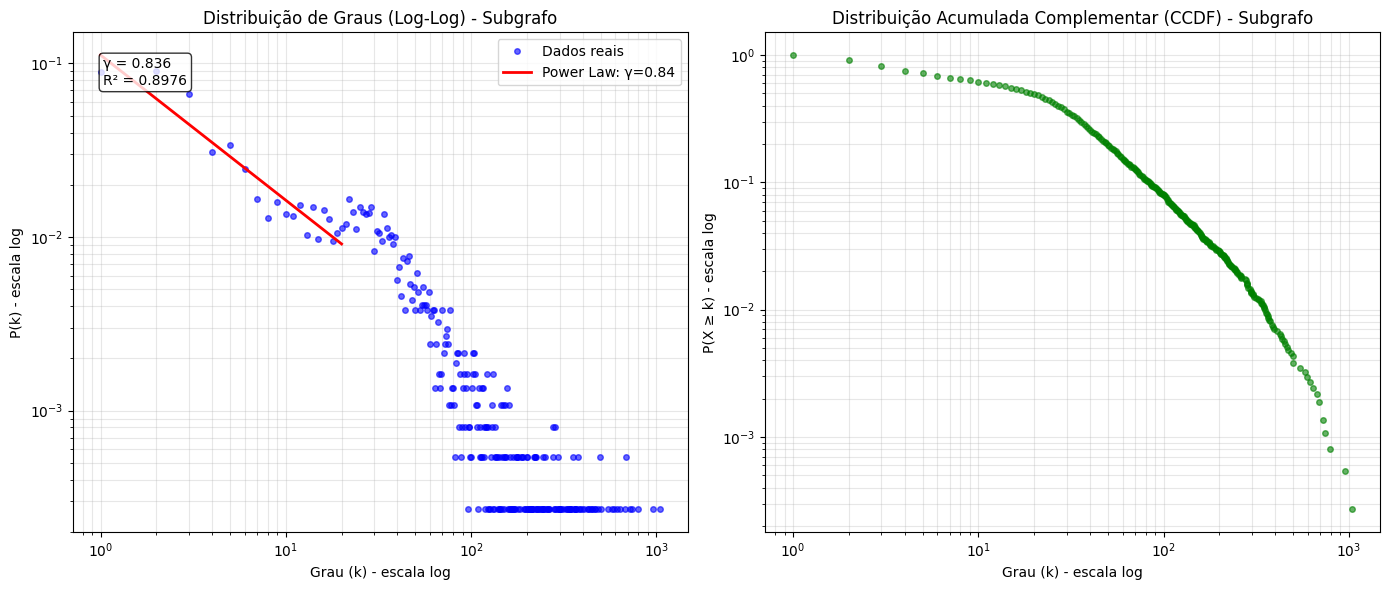

In [27]:
print("ANÁLISE DE LEI DE POTÊNCIA (SUBGRAFO)")

# Distribuição de graus
degrees_sub = [d for n, d in G_sub.degree()]
degree_counts = Counter(degrees_sub)
k_values = sorted(degree_counts.keys())
p_values = [degree_counts[k] / G_sub.number_of_nodes() for k in k_values]

# Usar apenas valores com k > 0
valid_indices = [i for i, k in enumerate(k_values) if k > 0]
k_filtered = [k_values[i] for i in valid_indices]
p_filtered = [p_values[i] for i in valid_indices]

log_k = np.log(k_filtered)
log_p = np.log(p_filtered)

# Remover cauda ruidosa (usar apenas os primeiros pontos)
num_points = min(20, len(log_k))
slope, intercept, r_value, p_value, std_err = stats.linregress(
    log_k[:num_points], log_p[:num_points]
)

gamma = -slope
print(f"  ✓ Expoente da lei de potência: γ = {gamma:.3f}")
print(f"  ✓ R² = {r_value**2:.4f}")

# Verificação se segue lei de potência
is_power_law = r_value**2 > 0.8 and gamma > 1

print(f"\n A distribuição {'segue' if is_power_law else 'NÃO segue'} uma lei de potência")
print(f"    - γ = {gamma:.3f} {'>' if gamma > 1 else '<='} 1")
print(f"    - R² = {r_value**2:.4f} {'>' if r_value**2 > 0.8 else '<='} 0.8")

# Gráfico da distribuição de graus
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico log-log
ax1.loglog(k_values, p_values, 'bo', markersize=4, alpha=0.6, label='Dados reais')
ax1.loglog(k_filtered[:num_points], np.exp(intercept + slope * log_k[:num_points]), 
           'r-', linewidth=2, label=f'Power Law: γ={gamma:.2f}')
ax1.set_xlabel('Grau (k) - escala log')
ax1.set_ylabel('P(k) - escala log')
ax1.set_title('Distribuição de Graus (Log-Log) - Subgrafo')
ax1.grid(True, alpha=0.3, which='both')
ax1.legend()

# Adicionar anotações
ax1.text(0.05, 0.95, f'γ = {gamma:.3f}\nR² = {r_value**2:.4f}', 
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# CCDF (Complementary Cumulative Distribution Function)
k_ccdf = sorted(k_values)
p_ccdf = [sum(p_values[i:]) for i in range(len(p_values))]

ax2.loglog(k_ccdf, p_ccdf, 'go', markersize=4, alpha=0.6)
ax2.set_xlabel('Grau (k) - escala log')
ax2.set_ylabel('P(X ≥ k) - escala log')
ax2.set_title('Distribuição Acumulada Complementar (CCDF) - Subgrafo')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('g96_power_law_subgraph.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
print("ANÁLISE DE ROBUSTEZ (SUBGRAFO)")

n_sub = G_sub.number_of_nodes()
r = int(0.05 * n_sub)  # 5% dos vértices
T = 30  # Número de repetições

print(f"Vértices no subgrafo: {n_sub:,}")
print(f"5% = {r} vértices")
print(f"Repetições: {T}")

# Funções para remoção e métricas
def calculate_metrics(G_after_removal):
    if G_after_removal.number_of_nodes() == 0:
        return {
            'largest_component': 0,
            'num_components': 0,
            'fraction_isolated': 1.0,
            'avg_distance': 0,
            'diameter': 0
        }
    
    components = list(nx.connected_components(G_after_removal))
    largest_comp = max([len(c) for c in components]) if components else 0
    largest_comp_norm = largest_comp / G_after_removal.number_of_nodes()
    
    num_components = len(components)
    
    isolated = [n for n, d in G_after_removal.degree() if d == 0]
    fraction_isolated = len(isolated) / G_after_removal.number_of_nodes()
    
    avg_distance = 0
    diameter = 0
    if G_after_removal.number_of_nodes() > 1:
        sample_nodes = np.random.choice(list(G_after_removal.nodes()), 
                                        size=min(50, G_after_removal.number_of_nodes()), 
                                        replace=False)
        all_distances = []
        for source in sample_nodes:
            try:
                lengths = nx.single_source_shortest_path_length(G_after_removal, source)
                all_distances.extend(lengths.values())
            except:
                continue
        if all_distances:
            avg_distance = np.mean(all_distances)
            diameter = max(all_distances)
    
    return {
        'largest_component': largest_comp_norm,
        'num_components': num_components,
        'fraction_isolated': fraction_isolated,
        'avg_distance': avg_distance,
        'diameter': diameter
    }

def random_removal(G, r):
    nodes = list(G.nodes())
    to_remove = np.random.choice(nodes, size=min(r, len(nodes)), replace=False)
    G_removed = G.copy()
    G_removed.remove_nodes_from(to_remove)
    return G_removed

def robustness_test(G, removal_type, r, T=30):
    metrics_list = []
    
    if removal_type == 'random':
        for i in range(T):
            G_removed = random_removal(G, r)
            metrics_list.append(calculate_metrics(G_removed))
    
    elif removal_type == 'degree':
        # Calcular degree uma vez
        degrees_nodes = [(n, d) for n, d in G.degree()]
        sorted_by_degree = sorted(degrees_nodes, key=lambda x: x[1], reverse=True)
        top_nodes = [n for n, d in sorted_by_degree[:r]]
        
        for i in range(T):
            G_removed = G.copy()
            G_removed.remove_nodes_from(top_nodes)
            metrics_list.append(calculate_metrics(G_removed))
    
    elif removal_type == 'betweenness':
        betweenness = nx.betweenness_centrality(G)
        sorted_by_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)
        top_nodes = [n for n, b in sorted_by_betweenness[:r]]
        
        for i in range(T):
            G_removed = G.copy()
            G_removed.remove_nodes_from(top_nodes)
            metrics_list.append(calculate_metrics(G_removed))
    
    return metrics_list

# Executar testes
random_metrics = robustness_test(G_sub, 'random', r, T=30)
degree_metrics = robustness_test(G_sub, 'degree', r, T=30)
betweenness_metrics = robustness_test(G_sub, 'betweenness', r, T=30)

# Processar resultados
def process_metrics(metrics_list, name=""):
    if not metrics_list:
        return None
    
    largest = [m['largest_component'] for m in metrics_list]
    components = [m['num_components'] for m in metrics_list]
    isolated = [m['fraction_isolated'] for m in metrics_list]
    avg_dist = [m['avg_distance'] for m in metrics_list if m['avg_distance'] > 0]
    
    return {
        'name': name,
        'largest_mean': np.mean(largest),
        'largest_std': np.std(largest),
        'components_mean': np.mean(components),
        'components_std': np.std(components),
        'isolated_mean': np.mean(isolated),
        'isolated_std': np.std(isolated),
        'avg_dist_mean': np.mean(avg_dist) if avg_dist else 0,
        'avg_dist_std': np.std(avg_dist) if avg_dist else 0,
        'data': {
            'largest': largest,
            'components': components,
            'isolated': isolated,
            'avg_dist': avg_dist
        }
    }

results_random = process_metrics(random_metrics, "Aleatório")
results_degree = process_metrics(degree_metrics, "Degree (Hubs)")
results_betweenness = process_metrics(betweenness_metrics, "Betweenness")

print("RESULTADOS DA ROBUSTEZ (SUBGRAFO)")

print("\nMétrica A - Tamanho da Maior Componente (normalizado):")
print(f"  - Aleatório:    {results_random['largest_mean']:.4f} ± {results_random['largest_std']:.4f}")
print(f"  - Degree:       {results_degree['largest_mean']:.4f} ± {results_degree['largest_std']:.4f}")
print(f"  - Betweenness:  {results_betweenness['largest_mean']:.4f} ± {results_betweenness['largest_std']:.4f}")

print("\nMétrica B - Número de Componentes:")
print(f"  - Aleatório:    {results_random['components_mean']:.1f} ± {results_random['components_std']:.1f}")
print(f"  - Degree:       {results_degree['components_mean']:.1f} ± {results_degree['components_std']:.1f}")
print(f"  - Betweenness:  {results_betweenness['components_mean']:.1f} ± {results_betweenness['components_std']:.1f}")

print("\nMétrica D - Fração de Nós Isolados:")
print(f"  - Aleatório:    {results_random['isolated_mean']:.4f} ± {results_random['isolated_std']:.4f}")
print(f"  - Degree:       {results_degree['isolated_mean']:.4f} ± {results_degree['isolated_std']:.4f}")
print(f"  - Betweenness:  {results_betweenness['isolated_mean']:.4f} ± {results_betweenness['isolated_std']:.4f}")

ANÁLISE DE ROBUSTEZ (SUBGRAFO)
Vértices no subgrafo: 3,707
5% = 185 vértices
Repetições: 30
    Calculando betweenness centrality (pode levar alguns segundos)...
RESULTADOS DA ROBUSTEZ (SUBGRAFO)

Métrica A - Tamanho da Maior Componente (normalizado):
  - Aleatório:    0.9947 ± 0.0015
  - Degree:       0.9443 ± 0.0000
  - Betweenness:  0.9267 ± 0.0000

Métrica B - Número de Componentes:
  - Aleatório:    19.6 ± 5.5
  - Degree:       197.0 ± 0.0
  - Betweenness:  259.0 ± 0.0

Métrica D - Fração de Nós Isolados:
  - Aleatório:    0.0053 ± 0.0015
  - Degree:       0.0557 ± 0.0000
  - Betweenness:  0.0733 ± 0.0000
